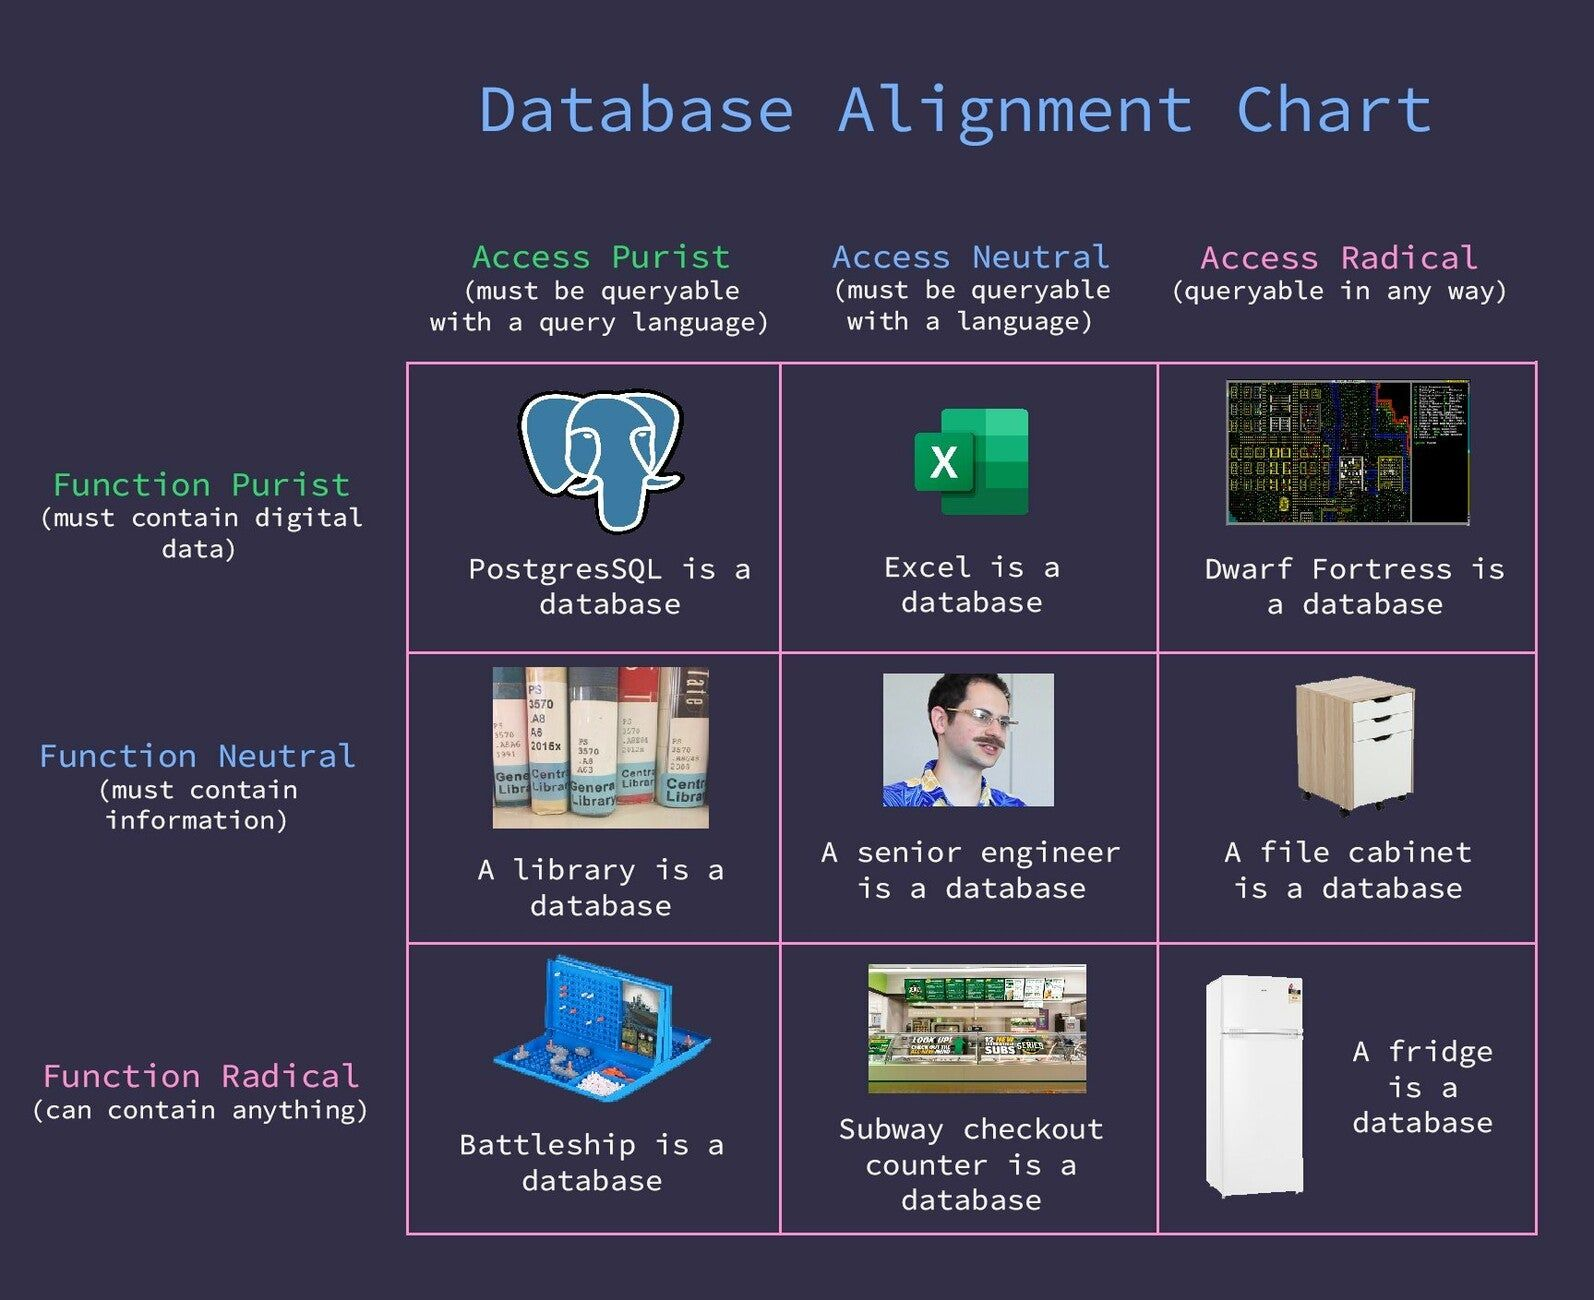

## 1.1 Что такое база данных?

База данных (БД) — это организованное хранилище данных, которое позволяет:
- хранить большие объёмы информации
- быстро искать и фильтровать данные
- обновлять и удалять данные
- работать с данными одновременно нескольким пользователям

### Почему не просто файл или Excel?

| | Excel / CSV | База данных |
|---|---|---|
| Объём данных | до ~миллиона строк | миллиарды строк |
| Скорость поиска | медленно | быстро (индексы) |
| Несколько пользователей | проблемы | поддерживается |
| Связи между данными | сложно | легко |
| Надёжность | низкая | высокая (транзакции) |

### Виды баз данных

Самый распространённый вид — реляционные БД. В них данные представляются как набор таблиц с фиксированными столбцами.  
Именно о них и пойдёт речь сегодня.

Примеры реляционных СУБД:
- SQLite — лёгкая, хранится в одном файле, идеальна для обучения
- PostgreSQL — мощная, популярна в продакшене
- MySQL / MariaDB — широко используется в веб-разработке
- Oracle, MS SQL Server — корпоративные решения

Нереляционные БД бывают разные, но, пожалуй, самые интересные -- те, которые хранят графы и позволяют проводить над ними операции. К сожалению, сегодня мы не успеем их коснуться.

## 1.2 Таблицы, строки, столбцы

Данные в реляционной БД хранятся в таблицах.  
Каждая таблица похожа на таблицу в Excel или DataFrame в pandas:

- Строка — объект (например, студент)
- Столбец — характеристика объекта (например, имя студента)
- Ячейка — значение конкретной характеристики конкретного объекта (например, Иван)

Пример таблицы `students`:

| id | name | age | gpa |
|---|---|---|---|
| 1 | Анна Смирнова | 18 | 4.8 |
| 2 | Иван Петров | 19 | 3.9 |
| 3 | Мария Кузнецова | 18 | 4.5 |

У каждой строки есть первичный ключ (Primary Key, PK) — уникальный идентификатор.
Обычно это поле `id` с автоматически увеличивающимся числом.
Строки в таблице отсортированы по первичному ключу, так что поиск по нему занимает O(log(N)), а по обычному столбцу -- O(N). C этим можно кое-что сделать, но об этом позже.


## 1.3 Связи между таблицами

Сила реляционных БД — в **связях между таблицами**.  
Вместо того чтобы дублировать данные, мы храним их один раз и ссылаемся на них.

Рассмотрим пример с университетом. Пусть у нас есть:
- Студенты
- Курсы
- Оценки (кто, за что, сколько)

### Плохой подход — всё в одной таблице:

| student_name | course_name | professor | grade |
|---|---|---|---|
| Анна Смирнова | Математика | Иванов И.И. | 5 |
| Анна Смирнова | Физика | Петров П.П. | 4 |
| Иван Петров | Математика | Иванов И.И. | 3 |

Проблемы:
- Имя преподавателя повторяется в каждой строке
- Если преподаватель сменит фамилию — нужно обновить много строк
- Легко допустить опечатку

### Хороший подход — несколько связанных таблиц:

Таблица `students`:  

| id | name |
|---|---|
| 1 | Анна Смирнова |
| 2 | Иван Петров |

Таблица `courses`:  

| id | name | professor |
|---|---|---|
| 1 | Математика | Иванов И.И. |
| 2 | Физика | Петров П.П. |

Таблица `grades`:  

| id | student_id | course_id | grade |
|---|---|---|---|
| 1 | 1 | 1 | 5 |
| 2 | 1 | 2 | 4 |
| 3 | 2 | 1 | 3 |

Поле `student_id` в таблице `grades` — это внешний ключ (Foreign Key, FK):  он ссылается на `id` в таблице `students`.


## 1.4 Нормализация

Нормализация — это процесс организации таблиц так, чтобы:
- минимизировать дублирование данных
- обеспечить логичную структуру

Пример выше с тремя таблицами вместо одной — это и есть нормализация. В идеале, каждое значение должно храниться только в одном месте.

Если вы видите, что одни и те же данные повторяются в нескольких строках —  скорее всего, таблицу стоит разбить на несколько.

Если захотите больше про это узнать, загуглите "нормальные формы в базах данных", там отдельная небольшая наука.

## 1.5 Индексы

Индекс в базе данных — позволяет быстро найти нужные строки, не перебирая всю таблицу.

Это некоторая дополнительная структура в таблице (в норме некоторое дерево поиска), которое позволяет сократить время поиска конкретного элемента с линейного до логарифмического. Не бесплатно, конечно: время добавления новых строк растёт, потому что нужно перестраивать индексы.

### Когда индексы создаются автоматически:
- Для первичного ключа — всегда
- Для внешних ключей — в большинстве СУБД

### Когда стоит добавить индекс вручную:
- Для столбцов, по которым часто ищут (например, `email`, `name`)


## 1.6 Транзакции

Транзакция — это группа операций, которые выполняются как единое целое. Например, перевод денег между клиентами. Будет неудобно, если деньги с вашего счёта снимутся, а другу не придут, правда? Это пример операции, которую нужно либо выполнить целиком, либо не выполнять вообще.

### Требования к транзакциям, aka ACID:
| Свойство | Описание |
|---|---|
| **A**tomicity (Атомарность) | Всё или ничего |
| **C**onsistency (Согласованность) | БД остаётся в корректном состоянии |
| **I**solation (Изолированность) | Транзакции не мешают друг другу |
| **D**urability (Долговечность) | Результат сохраняется даже при сбое |

## Часть 2. SQL

**SQL (Structured Query Language)** — язык запросов к реляционным базам данных.  
С его помощью мы говорим БД что сделать: найти, добавить, изменить, удалить данные.

SQL используется во всех реляционных СУБД (с небольшими отличиями в диалектах).

### Основные группы команд:
| Группа | Команды | Назначение |
|---|---|---|
| **DML** | SELECT, INSERT, UPDATE, DELETE | Работа с данными |
| **DDL** | CREATE, ALTER, DROP | Работа со структурой |
| **TCL** | COMMIT, ROLLBACK | Управление транзакциями |

Сегодня мы сосредоточимся на **DML**, и в первую очередь на **SELECT**.


In [37]:
# Для работы с ноутбуком нам понадобятся эти библиотеки
# Установка (если нужно):
# pip install sqlalchemy pandas

import sqlite3
import pandas as pd
from sqlalchemy import (
    create_engine, text,
    Column, Integer, String, Float, ForeignKey
)
from sqlalchemy.orm import (
    DeclarativeBase, Session,
    relationship, joinedload
)


In [6]:
# Создадим базу данных университета и заполним её данными
# Будем использовать sqlite3 напрямую, чтобы понять основы

conn = sqlite3.connect(":memory:")  # БД в памяти, не создаёт файл
cursor = conn.cursor()

# SELECT true AND NULL
# false: 1
# null -- правильный ответ

# SELECT true OR NULL
# SELECT NULL OR true
# true -- правильный ответ
# SELECT false AND NULL
# false -- правильный ответ

# Создание таблиц
cursor.executescript("""
    CREATE TABLE departments (
        id      INTEGER PRIMARY KEY,
        name    TEXT NOT NULL
    );

    CREATE TABLE professors (
        id            INTEGER PRIMARY KEY,
        name          TEXT NOT NULL,
        department_id INTEGER REFERENCES departments(id)
    );

    CREATE TABLE students (
        id            INTEGER PRIMARY KEY,
        name          TEXT NOT NULL,
        age           INTEGER,
        department_id INTEGER REFERENCES departments(id)
    );

    CREATE TABLE courses (
        id           INTEGER PRIMARY KEY,
        name         TEXT NOT NULL,
        professor_id INTEGER REFERENCES professors(id)
    );

    CREATE TABLE enrollments (
        id         INTEGER PRIMARY KEY,
        student_id INTEGER REFERENCES students(id),
        course_id  INTEGER REFERENCES courses(id),
        grade      INTEGER  -- оценка от 1 до 5
    );
""")

# Заполнение данными
cursor.executescript("""
    INSERT INTO departments VALUES
        (1, 'Математика'),
        (2, 'Физика'),
        (3, 'Информатика');

    INSERT INTO professors VALUES
        (1, 'Иванов И.И.',  1),
        (2, 'Петров П.П.', 2),
        (3, 'Сидоров С.С.', 3),
        (4, 'Козлова К.К.', 3);

    INSERT INTO students VALUES
        (1,  'Анна Смирнова',    18, 1),
        (2,  'Иван Петров',      19, 1),
        (3,  'Мария Кузнецова',  18, 2),
        (4,  'Алексей Новиков',  20, 2),
        (5,  'Елена Морозова',   19, 3),
        (6,  'Дмитрий Волков',   18, 3),
        (7,  'Ольга Соколова',   19, 1),
        (8,  'Андрей Лебедев',   20, 3),
        (9,  'Наталья Козлова',  18, 2),
        (10, 'Сергей Новиков',   19, 3);

    INSERT INTO courses VALUES
        (1, 'Математический анализ', 1),
        (2, 'Линейная алгебра',      1),
        (3, 'Механика',              2),
        (4, 'Алгоритмы',             3),
        (5, 'Базы данных',           4);

    INSERT INTO enrollments VALUES
        (1,  1, 1, 5), (2,  1, 2, 4), (3,  1, 4, 5),
        (4,  2, 1, 3), (5,  2, 2, 4),
        (6,  3, 3, 4), (7,  3, 5, 5),
        (8,  4, 3, 2), (9,  4, 1, 3),
        (10, 5, 4, 5), (11, 5, 5, 4),
        (12, 6, 4, 3), (13, 6, 5, 4),
        (14, 7, 1, 4), (15, 7, 2, 5),
        (16, 8, 4, 5), (17, 8, 5, 3),
        (18, 9, 3, 4), (19, 9, 1, 5),
        (20, 10, 4, 4),(21, 10, 5, 5);
""")

conn.commit()


In [7]:
# Вспомогательная функция: выполнить запрос и показать результат как DataFrame
def query(sql, conn=conn):
    return pd.read_sql_query(sql, conn)

## 2.1 SELECT — извлечение данных

`SELECT` — позволяет извлекать данные из таблиц -- а также группировать их, фильтровать, считать статистики, преобразовывать, сортировать, и, глобально, совершать над ними любые действия.

```sql
SELECT столбцы
FROM таблица
WHERE условие
ORDER BY столбец
LIMIT количество;
```


In [8]:
query("SELECT * FROM students")

,id,name,age,department_id
0,1,Анна Смирнова,18,1
1,2,Иван Петров,19,1
2,3,Мария Кузнецова,18,2
3,4,Алексей Новиков,20,2
4,5,Елена Морозова,19,3
5,6,Дмитрий Волков,18,3
6,7,Ольга Соколова,19,1
7,8,Андрей Лебедев,20,3
8,9,Наталья Козлова,18,2
9,10,Сергей Новиков,19,3


In [38]:
query("SELECT age FROM students")

,age
0,18
1,19
2,18
3,20
4,19
5,18
6,19
7,20
8,18
9,19


In [40]:
query("SELECT DISTINCT age FROM students")

,age
0,18
1,19
2,20


## 2.2 WHERE — фильтрация

`WHERE` позволяет отфильтровать строки по условию.

| Оператор | Пример |
|---|---|
| `=` | `age = 18` |
| `!=` или `<>` | `age != 18` |
| `>`, `<`, `>=`, `<=` | `age >= 19` |
| `AND`, `OR`, `NOT` | `age = 18 AND department_id = 1` |
| `BETWEEN` | `age BETWEEN 18 AND 19` |
| `IN` | `department_id IN (1, 3)` |
| `LIKE` | `name LIKE 'А%'` — начинается с А |
| `IS NULL` | `grade IS NULL` |


In [10]:
# Студенты с кафедры информатики
query("SELECT * FROM students WHERE department_id = 3")

,id,name,age,department_id
0,5,Елена Морозова,19,3
1,6,Дмитрий Волков,18,3
2,8,Андрей Лебедев,20,3
3,10,Сергей Новиков,19,3


In [41]:
query("SELECT * FROM students WHERE age = 20")

,id,name,age,department_id
0,4,Алексей Новиков,20,2
1,8,Андрей Лебедев,20,3


## 2.3 ORDER BY и LIMIT

`ORDER BY` — сортировка результата.  
`LIMIT` — ограничение количества строк.

In [11]:
# Топ-3 самых молодых студента
query("""
    SELECT * FROM students
    ORDER BY age ASC
    LIMIT 3
""")

,id,name,age,department_id
0,1,Анна Смирнова,18,1
1,3,Мария Кузнецова,18,2
2,6,Дмитрий Волков,18,3


In [42]:
query("""
    SELECT * FROM students
    LIMIT 3
""")

,id,name,age,department_id
0,1,Анна Смирнова,18,1
1,2,Иван Петров,19,1
2,3,Мария Кузнецова,18,2


## 2.4 Агрегатные функции и GROUP BY

Агрегатные функции вычисляют одно значение на основе группы строк:

| Функция | Описание |
|---|---|
| `count(*)` | Количество строк |
| `sum(col)` | Сумма |
| `avg(col)` | Среднее |
| `min(col)` | Минимум |
| `max(col)` | Максимум |
| `count(name)` | число непустых имён |
| `count(distinct name)` | число уникальных непустых имён |

`GROUP BY` группирует строки перед применением агрегатной функции.

Если в запросе есть `GROUP BY` по набору столбцов, то в `SELECT` можно писать только эти столбцы и агрегатные функции над любыми столбцами. Некоторые БД просто запрещают использовать остальные столбцы, другие скатываются в какое-то специфичное этой БД поведение.


In [49]:
# Сколько всего студентов?
query(""" 
      SELECT
          department_id,
          COUNT(distinct age) AS unique_ages, 
          min(age), 
          max(age) 
      FROM students
      GROUP BY department_id
""")

,department_id,unique_ages,min(age),max(age)
0,1,2,18,19
1,2,2,18,20
2,3,3,18,20


In [55]:
# Сколько всего студентов?
query(""" 
      SELECT
          age,
          department_id,
          count(*),
          count(distinct department_id)
      FROM students
      GROUP BY age
""")

,age,department_id,count(*),count(distinct department_id)
0,18,2,4,3
1,19,3,4,2
2,20,3,2,2


In [50]:
query("SELECT * FROM students ORDER BY age")

,id,name,age,department_id
0,1,Анна Смирнова,18,1
1,3,Мария Кузнецова,18,2
2,6,Дмитрий Волков,18,3
3,9,Наталья Козлова,18,2
4,2,Иван Петров,19,1
5,5,Елена Морозова,19,3
6,7,Ольга Соколова,19,1
7,10,Сергей Новиков,19,3
8,4,Алексей Новиков,20,2
9,8,Андрей Лебедев,20,3


In [13]:
# Количество студентов на каждой кафедре
query("""
    SELECT 
        department_id,
        COUNT(*) AS student_count
    FROM students
    GROUP BY department_id
""")

,department_id,student_count
0,1,3
1,2,3
2,3,4


In [15]:
# Количество студентов на каждой кафедре + поле не из GROUP BY
query("""
    SELECT 
        department_id,
        name,
        COUNT(*) AS student_count
    FROM students
    GROUP BY department_id
""")

,department_id,name,student_count
0,1,Ольга Соколова,3
1,2,Наталья Козлова,3
2,3,Сергей Новиков,4


## 2.5 JOIN — объединение таблиц

`JOIN` позволяет объединять данные из нескольких таблиц по столбцам с пересекающимися значениями. Например, приклеить в таблицу название кафедры по id этой кафедры.

```sql
SELECT ...
FROM таблица_а
JOIN таблица_б ON таблица_а.ключ = таблица_б.ключ
```

### Типы JOIN:
- INNER JOIN — только строки, для которых есть совпадение в обеих таблицах
- LEFT JOIN — все строки из левой таблицы + совпадения из правой (если нет совпадения — NULL)
- RIGHT JOIN — наоборот (в SQLite не поддерживается, но есть в других СУБД)
- FULL OUTER JOIN — все строки из обеих таблиц

Чаще всего используют INNER JOIN и LEFT JOIN.


In [18]:
# Студенты с названием их кафедры (INNER JOIN)
query("""
    SELECT 
        s.name AS student_name,
        s.age,
        d.name AS department_name
    FROM students s
    INNER JOIN departments d ON s.department_id = d.id
""")

,student_name,age,department_name
0,Анна Смирнова,18,Математика
1,Иван Петров,19,Математика
2,Мария Кузнецова,18,Физика
3,Алексей Новиков,20,Физика
4,Елена Морозова,19,Информатика
5,Дмитрий Волков,18,Информатика
6,Ольга Соколова,19,Математика
7,Андрей Лебедев,20,Информатика
8,Наталья Козлова,18,Физика
9,Сергей Новиков,19,Информатика


In [61]:
query("SELECT age FROM students ORDER BY age")

,age
0,18
1,18
2,18
3,18
4,19
5,19
6,19
7,19
8,20
9,20


In [60]:
query("""
    SELECT s1.name, s2.name
    FROM students AS s1
    INNER JOIN students AS s2 ON s1.age = s2.age
""")

,name,name
0,Анна Смирнова,Анна Смирнова
1,Анна Смирнова,Дмитрий Волков
2,Анна Смирнова,Мария Кузнецова
3,Анна Смирнова,Наталья Козлова
4,Иван Петров,Елена Морозова
5,Иван Петров,Иван Петров
6,Иван Петров,Ольга Соколова
7,Иван Петров,Сергей Новиков
8,Мария Кузнецова,Анна Смирнова
9,Мария Кузнецова,Дмитрий Волков


In [19]:
# GROUP BY + JOIN: средняя оценка студентов по кафедрам
query("""
    SELECT 
        d.name AS department,
        COUNT(DISTINCT s.id) AS student_count,
        ROUND(AVG(e.grade), 2) AS avg_grade
    FROM students s
    INNER JOIN departments AS d ON s.department_id = d.id
    INNER JOIN enrollments AS e ON e.student_id = s.id
    GROUP BY d.id, d.name
    ORDER BY avg_grade DESC
""")

,department,student_count,avg_grade
0,Математика,3,4.29
1,Информатика,4,4.13
2,Физика,3,3.83


Порядок выполнения запроса

FROM

JOIN

WHERE

GROUP BY

SELECT

ORDER BY

LIMIT

## 2.6 Подзапросы

Подзапрос — это запрос внутри другого запроса.  
Результат внутреннего запроса используется во внешнем.

Подзапросы бывают:
- В `WHERE` — для фильтрации по результату другого запроса
- В `FROM` — как временная таблица
- В `SELECT` — как вычисляемый столбец

In [67]:
query("""
    SELECT 
        s.name, 
        d.department_id, 
        d.num
    FROM students AS s
    INNER JOIN (
        SELECT department_id, count(*) AS num
        FROM students 
        GROUP BY department_id
    ) AS d ON s.department_id = d.department_id
""")

,name,department_id,num
0,Анна Смирнова,1,3
1,Иван Петров,1,3
2,Мария Кузнецова,2,3
3,Алексей Новиков,2,3
4,Елена Морозова,3,4
5,Дмитрий Волков,3,4
6,Ольга Соколова,1,3
7,Андрей Лебедев,3,4
8,Наталья Козлова,2,3
9,Сергей Новиков,3,4


In [66]:
query("SELECT department_id, count(*) AS num FROM students GROUP BY department_id")

,count(*)
0,3
1,3
2,4


In [20]:
# Подзапрос в FROM:
# Сначала считаем среднюю оценку по каждому курсу,
# затем берём курсы с оценкой выше 4

query("""
    SELECT 
        course_stats.course_id,
        c.name AS course_name,
        course_stats.avg_grade
    FROM (
        SELECT 
            course_id,
            ROUND(AVG(grade), 2) AS avg_grade
        FROM enrollments
        GROUP BY course_id
    ) AS course_stats
    INNER JOIN courses c ON c.id = course_stats.course_id
    WHERE course_stats.avg_grade > 4
    ORDER BY course_stats.avg_grade DESC
""")


,name,avg_grade
0,Анна Смирнова,4.67
1,Мария Кузнецова,4.50
2,Елена Морозова,4.50
3,Ольга Соколова,4.50
4,Наталья Козлова,4.50
5,Сергей Новиков,4.50


In [ ]:
# Подзапрос в WHERE:
# Найти студентов, чья средняя оценка выше средней по университету

query("""
    SELECT 
        s.name,
        ROUND(AVG(e.grade), 2) AS avg_grade
    FROM students s
    JOIN enrollments e ON e.student_id = s.id
    GROUP BY s.id, s.name
    HAVING AVG(e.grade) > (
        SELECT AVG(grade) FROM enrollments
    )
    ORDER BY avg_grade DESC
""")

In [24]:
# Проверяем

query("""
    SELECT 
        s.name,
        ROUND(AVG(grade), 2) AS avg_grade
    FROM students s
    INNER JOIN enrollments e ON e.student_id = s.id
    GROUP BY s.id, s.name
    ORDER BY grade DESC
""")

,name,avg_grade
0,Анна Смирнова,4.67
1,Мария Кузнецова,4.50
2,Ольга Соколова,4.50
3,Наталья Козлова,4.50
4,Сергей Новиков,4.50
5,Иван Петров,3.50
6,Елена Морозова,4.50
7,Дмитрий Волков,3.50
8,Алексей Новиков,2.50
9,Андрей Лебедев,4.00


In [21]:
query("SELECT AVG(grade) FROM enrollments")

,AVG(grade)
0,4.095238


## Часть 3. SQLAlchemy ORM

Писать SQL вручную — нормально, но в реальных проектах это неудобно:
- Строки SQL легко сломать опечаткой
- Нет автодополнения и проверки типов
- Сложно поддерживать большой код

SQLAlchemy — самая популярная библиотека для работы с БД в Python.

Она предоставляет два уровня:
- Core — тонкая обёртка над SQL
- ORM (Object-Relational Mapping) — работа с БД через обычные Python-объекты

Сегодня мы изучим ORM.

### Идея ORM:
> Каждая таблица в БД — это Python-класс.  
> Каждая строка в таблице — это объект этого класса.  
> Операции с данными — это методы и атрибуты объектов.

In [72]:
# Создадим новое подключение через SQLAlchemy
# echo=True — будет печатать SQL-запросы, которые генерирует SQLAlchemy

engine = create_engine("sqlite:///university.db", echo=False)

## 3.1 Определение моделей

В SQLAlchemy ORM каждая таблица описывается классом-моделью.  
Все модели наследуются от базового класса `Base`.


In [73]:
# Базовый класс для всех моделей
class Base(DeclarativeBase):
    pass


# Модель кафедры
class Department(Base):
    __tablename__ = "departments"

    id   = Column(Integer, primary_key=True)
    name = Column(String, nullable=False)

    # Связи (рассмотрим подробнее позже)
    professors = relationship("Professor", back_populates="department")
    students   = relationship("Student",   back_populates="department")

    def __repr__(self):
        return f"Department(id={self.id}, name='{self.name}')"


# Модель преподавателя
class Professor(Base):
    __tablename__ = "professors"

    id            = Column(Integer, primary_key=True)
    name          = Column(String, nullable=False)
    department_id = Column(Integer, ForeignKey("departments.id"))

    department = relationship("Department", back_populates="professors")
    courses    = relationship("Course",     back_populates="professor")

    def __repr__(self):
        return f"Professor(id={self.id}, name='{self.name}')"


# Модель студента
class Student(Base):
    __tablename__ = "students"

    id            = Column(Integer, primary_key=True)
    name          = Column(String,  nullable=False)
    age           = Column(Integer)
    department_id = Column(Integer, ForeignKey("departments.id"))

    department  = relationship("Department",  back_populates="students")
    enrollments = relationship("Enrollment",  back_populates="student")

    def __repr__(self):
        return f"Student(id={self.id}, name='{self.name}', age={self.age})"


# Модель курса
class Course(Base):
    __tablename__ = "courses"

    id           = Column(Integer, primary_key=True)
    name         = Column(String,  nullable=False)
    professor_id = Column(Integer, ForeignKey("professors.id"))

    professor   = relationship("Professor",  back_populates="courses")
    enrollments = relationship("Enrollment", back_populates="course")

    def __repr__(self):
        return f"Course(id={self.id}, name='{self.name}')"


# Модель записи на курс (связующая таблица с дополнительным полем)
class Enrollment(Base):
    __tablename__ = "enrollments"

    id         = Column(Integer, primary_key=True)
    student_id = Column(Integer, ForeignKey("students.id"))
    course_id  = Column(Integer, ForeignKey("courses.id"))
    grade      = Column(Integer)

    student = relationship("Student", back_populates="enrollments")
    course  = relationship("Course",  back_populates="enrollments")

    def __repr__(self):
        return f"Enrollment(student_id={self.student_id}, course_id={self.course_id}, grade={self.grade})"


# Создаём все таблицы в БД
Base.metadata.create_all(engine)

## 3.2 Session — сессия работы с БД

В SQLAlchemy все операции выполняются через Session (сессию).  
Сессия:
- отслеживает изменения объектов
- управляет транзакциями
- отправляет запросы в БД

Лучший способ работать с сессией — через контекстный менеджер (`with`): он автоматически закроет сессию и откатит транзакцию при ошибке.


In [74]:
# Заполним базу данных через ORM

with Session(engine) as session:
    # Создаём кафедры
    math_dept = Department(name="Математика")
    phys_dept = Department(name="Физика")
    cs_dept   = Department(name="Информатика")
    session.add_all([math_dept, phys_dept, cs_dept])
    session.flush()  # отправляем в БД, но не фиксируем — чтобы получить id

    # Создаём преподавателей
    prof1 = Professor(name="Иванов И.И.",   department=math_dept)
    prof2 = Professor(name="Петров П.П.",   department=phys_dept)
    prof3 = Professor(name="Сидоров С.С.", department=cs_dept)
    prof4 = Professor(name="Козлова К.К.", department=cs_dept)
    session.add_all([prof1, prof2, prof3, prof4])
    session.flush()

    # Создаём студентов
    students = [
        Student(name="Анна Смирнова",   age=18, department=math_dept),
        Student(name="Иван Петров",      age=19, department=math_dept),
        Student(name="Мария Кузнецова",  age=18, department=phys_dept),
        Student(name="Алексей Новиков",  age=20, department=phys_dept),
        Student(name="Елена Морозова",   age=19, department=cs_dept),
        Student(name="Дмитрий Волков",   age=18, department=cs_dept),
        Student(name="Ольга Соколова",   age=19, department=math_dept),
        Student(name="Андрей Лебедев",   age=20, department=cs_dept),
        Student(name="Наталья Козлова",  age=18, department=phys_dept),
        Student(name="Сергей Новиков",   age=19, department=cs_dept),
    ]
    session.add_all(students)
    session.flush()

    # Создаём курсы
    course1 = Course(name="Математический анализ", professor=prof1)
    course2 = Course(name="Линейная алгебра",       professor=prof1)
    course3 = Course(name="Механика",               professor=prof2)
    course4 = Course(name="Алгоритмы",              professor=prof3)
    course5 = Course(name="Базы данных",            professor=prof4)
    session.add_all([course1, course2, course3, course4, course5])
    session.flush()

    # Создаём записи на курсы
    anna, ivan, maria, alexey, elena, dmitry, olga, andrey, natasha, sergey = students
    enrollments = [
        Enrollment(student=anna,   course=course1, grade=5),
        Enrollment(student=anna,   course=course2, grade=4),
        Enrollment(student=anna,   course=course4, grade=5),
        Enrollment(student=ivan,   course=course1, grade=3),
        Enrollment(student=ivan,   course=course2, grade=4),
        Enrollment(student=maria,  course=course3, grade=4),
        Enrollment(student=maria,  course=course5, grade=5),
        Enrollment(student=alexey, course=course3, grade=2),
        Enrollment(student=alexey, course=course1, grade=3),
        Enrollment(student=elena,  course=course4, grade=5),
        Enrollment(student=elena,  course=course5, grade=4),
        Enrollment(student=dmitry, course=course4, grade=3),
        Enrollment(student=dmitry, course=course5, grade=4),
        Enrollment(student=olga,   course=course1, grade=4),
        Enrollment(student=olga,   course=course2, grade=5),
        Enrollment(student=andrey, course=course4, grade=5),
        Enrollment(student=andrey, course=course5, grade=3),
        Enrollment(student=natasha,course=course3, grade=4),
        Enrollment(student=natasha,course=course1, grade=5),
        Enrollment(student=sergey, course=course4, grade=4),
        Enrollment(student=sergey, course=course5, grade=5),
    ]
    session.add_all(enrollments)
    session.commit()  # фиксируем все изменения

## 3.3 Чтение данных (SELECT)

Для запросов в SQLAlchemy ORM используется `session.query()`.

```python
# Базовый синтаксис
session.query(МодельКласса).all()        # все записи
session.query(МодельКласса).first()      # первая запись
session.query(МодельКласса).get(id)      # запись по id
```


In [79]:
# Получить всех студентов
with Session(engine) as session:
    students = session.query(Student).all()
    for student in students:
        print(student)

Student(id=1, name='Анна Смирнова', age=18)
Student(id=2, name='Иван Петров', age=19)
Student(id=3, name='Мария Кузнецова', age=18)
Student(id=4, name='Алексей Новиков', age=20)
Student(id=5, name='Елена Морозова', age=19)
Student(id=6, name='Дмитрий Волков', age=18)
Student(id=7, name='Ольга Соколова', age=19)
Student(id=8, name='Андрей Лебедев', age=20)
Student(id=9, name='Наталья Козлова', age=18)
Student(id=10, name='Сергей Новиков', age=19)


In [76]:
# Несколько условий — аналог AND
with Session(engine) as session:
    result = (
        session.query(Student)
        .filter(Student.age == 19, Student.department_id == 3)
        .all()
    )
    for s in result:
        print(s)

Student(id=5, name='Елена Морозова', age=19)
Student(id=10, name='Сергей Новиков', age=19)


In [78]:
# Джойны и агрегация

# Импортируем функции для агрегации
from sqlalchemy import func

# Средняя оценка каждого студента
with Session(engine) as session:
    results = (
        session.query(
            Student.name,
            func.round(func.avg(Enrollment.grade), 2).label("avg_grade")
        )
        .join(Enrollment, Student.id == Enrollment.student_id)
        .group_by(Student.id, Student.name)
        .order_by(func.avg(Enrollment.grade).desc())
        .all()
    )

    for name, avg_grade in results:
        print(f"{name}: {avg_grade}")


Анна Смирнова: 4.67
Мария Кузнецова: 4.5
Елена Морозова: 4.5
Ольга Соколова: 4.5
Наталья Козлова: 4.5
Сергей Новиков: 4.5
Андрей Лебедев: 4.0
Иван Петров: 3.5
Дмитрий Волков: 3.5
Алексей Новиков: 2.5


In [71]:
# Очистка: удаляем файл БД после работы
import os
if os.path.exists("university.db"):
    os.remove("university.db")